<div class='alert alert-block alert-info"'>
<h1> An sdg4varselect example :</h1>

<h4> Estimation in an Mixed-effect models </h4>

In [2]:
import sdg4varselect.plot as sdgplt
import jax.numpy as jnp
import jax.random as jrd

sdgplt.FIGSIZE = 10

### Mixed Effects Model Specification

First, let's define the model with the abstract object AbstractMixedEffectsModel. We want to define the following logisitc models :

$$ \left\{\begin{array}{rll}
            Y_{i,j} &= m(t_{i,j}; \varphi_i) + \varepsilon_{i,j}
            \\ \varphi_i \sim \mathcal N(\mu, \Gamma)   
            & ; ~\varepsilon_{i,j} \sim \mathcal N(0,\sigma^2).             
        \end{array}\right. ~ \forall i \in\{1,...,N\}, j\in\{1,...,J\}$$

where : $m(t_{i,j}; \varphi_i) = \frac{\varphi_{1,i}}{1+\exp\left(\frac{\varphi_{2,i}-t_{i,j}}{\tau} \right)}$ 

In [3]:
# pylint: disable=C0116, W0221
import functools
from jax import jit
import parametrization_cookbook.jax as pc

from sdg4varselect.models import AbstractMixedEffectsModel


class LogisticMixedEffectsModel(AbstractMixedEffectsModel):
    """define a logistic mixed effects model"""

    def __init__(self, N=1, J=1, **kwargs):
        super().__init__(
            N=N,
            J=J,
            me_name=["phi1", "phi2"],
            **kwargs,
        )

        self._parametrization = pc.NamedTuple(
            mean_latent=pc.NamedTuple(
                asymptotic=pc.RealPositive(scale=100),
                inflexion=pc.Real(loc=100, scale=100),
            ),
            tau=pc.RealPositive(scale=100),
            cov_latent=pc.MatrixDiagPosDef(dim=2, scale=(200, 200)),
            var_residual=pc.RealPositive(scale=100),
        )

    # ============================================================== #
    @functools.partial(jit, static_argnums=0)
    def mixed_effect_function(
        self,
        params,
        times: jnp.ndarray,  # shape = (J,) [None, :]
        phi1: jnp.ndarray,  # shape = (N,) [:,None]
        phi2: jnp.ndarray,  # shape = (N,) [:,None]
        **kwargs,
    ) -> jnp.ndarray:  # shape = (N,J)
        """logistic_curve
        phi1 = asymptotic
        phi2 = inflexion
        """

        out = phi1[:, None] / (1 + jnp.exp(-(times - phi2[:, None]) / params.tau))
        assert out.shape == times.shape
        return out

    # ============================================================== #

    def sample(
        self,
        params_star,
        prngkey,
        **kwargs,
    ):
        """Sample one data set for the model"""

        (
            prngkey_time,
            prngkey_mem,
        ) = jrd.split(prngkey, num=2)

        # === nlmem_simulation() === #
        time = jnp.linspace(100, 1500, self.J)
        time = jnp.tile(time, (self.N, 1))
        time += 10 * jrd.uniform(prngkey_time, minval=-2, maxval=2, shape=time.shape)

        obs, sim = AbstractMixedEffectsModel.sample(
            self, params_star, prngkey_mem, mem_obs_time=time
        )

        return {"mem_obs_time": time} | obs, sim

### Joint Model Specification

$$ \left\{\begin{array}{rll}
            h(t|U_i) 
            &=h_{0}(t) \exp(\beta^T U_i + \alpha m(t,\varphi_i))
            \\ Y_{i,j} &= m(t_j; \varphi_i) + \varepsilon_{i,j}
            \\ \varphi_i \sim \mathcal N(\mu, \Gamma)   
            & ; ~\varepsilon_{i,j} \sim \mathcal N(0,\sigma^2).             
        \end{array}\right. ~ \forall i \in\{1,...,N\}, j\in\{1,...,J\}$$

where : $h_{0}(t)= b a^{-b} t^{b-1}$ with $a=80$ and $b=35$

In [4]:
from sdg4varselect.models import WeibullCoxJM

# joint model with coxModel is all ready implement in sdg4varselect for all MixedEffectsModel
myMeModel = LogisticMixedEffectsModel(N=200, J=15)
myModel = WeibullCoxJM(myMeModel, P=4, alpha_scale=0.001, a=800, b=10)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


### Data Generation
Then we can generate a data set with $N=1000$ individuals and $J=20$ observation time per individuals

0.00011473894119262695


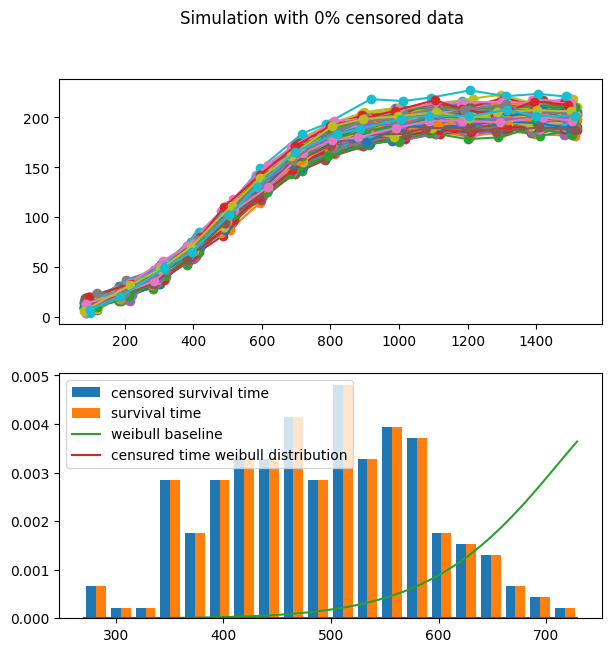

In [5]:
p_star = myModel.new_params(
    mean_latent={"asymptotic": 200, "inflexion": 500},
    tau=150,
    cov_latent=jnp.diag(jnp.array([40, 100])),
    var_residual=10,
    alpha=0.05,
    beta=jnp.concatenate(  # jnp.zeros(shape=(myModel.P,)),  #
        [jnp.array([-3, -2, 2, 3]), jnp.zeros(shape=(myModel.P - 4,))]
    ),
)

myobs, mysim = myModel.sample(p_star, jrd.PRNGKey(0), weibull_censoring_loc=7700)
fig, ax = sdgplt.plot_sample(myobs, mysim, censoring_loc=7700, **myModel._cst)

# Estimation example

Let's do an estimation of the parameter with the SGD-FIM algorithm

first we need to intiate the algorithm with accurate step size.

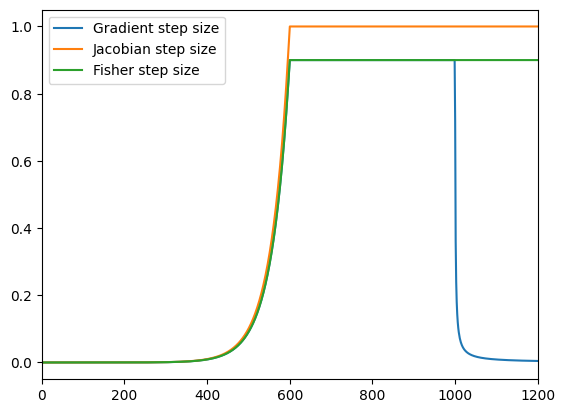

In [6]:
from sdg4varselect.outputs import GDResults, MultiRunRes
from sdg4varselect.algo import SPGD_FIM, get_GDFIM_settings
from sdg4varselect.learning_rate import create_multi_step_size

algo_settings = get_GDFIM_settings(preheating=600, heating=1000, learning_rate=1e-6)
step_sizes = create_multi_step_size(list(algo_settings))
labels = ["Gradient step size", "Jacobian step size", "Fisher step size"]
[lr.plot(label=labels[i]) for i, lr in enumerate(step_sizes)]
sdgplt.plt.legend()
_ = sdgplt.plt.xlim(0, 1200)

We define a function that make one estimation run. we set $\varphi_1$ and $\varphi_2$ as latente variable, and use a MCMC-procedure in the algorithm to treat them :

In [7]:
def one_estim(prngkey, model, data, lbd=None, save_all=True):
    prngkey_theta, prngkey_estim = jrd.split(prngkey)
    theta0 = 0.2 * jrd.normal(prngkey_theta, shape=(model.parametrization.size,))

    algo = SPGD_FIM(prngkey_estim, 10000, algo_settings, lbd=lbd, alpha=1.0)
    # =================== MCMC configuration ==================== #
    algo.init_mcmc(theta0, model, sd={"phi1": 5, "phi2": 20})

    for var_lat in algo.latent_variables.values():
        var_lat.adaptative_sd = True
    # ==================== END configuration ==================== #
    res = algo.fit(model, data, theta0, ntry=5, partial_fit=False, save_all=save_all)

    # sdgplt.plot_mcmc(algo.latent_variables)

    return res  # , algo

Now we perform severals estimations : 

In [8]:
from datetime import datetime

chrono_start = datetime.now()
multi_res = MultiRunRes(
    [one_estim(jrd.PRNGKey(key), myModel, myobs, save_all=True) for key in range(1)]
)
if "multi_res" not in locals():
    multi_res = MultiRunRes.load(myModel)
print(f"\ntotal = {datetime.now() - chrono_start} ")


total = 0:00:13.131463 


We can obtain the calculation time

In [9]:
print(multi_res.chrono)

0:00:12.944471


And plot the results

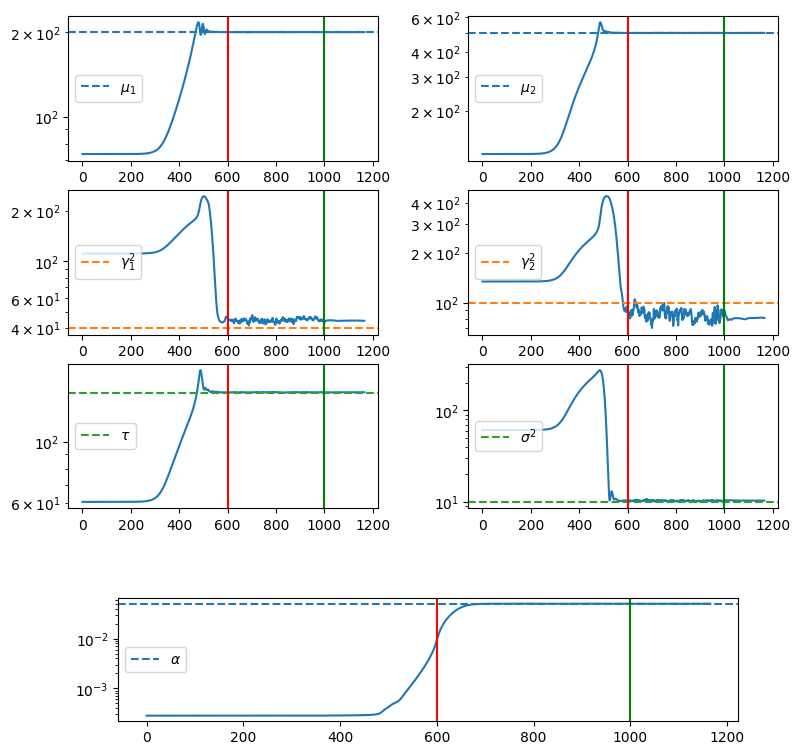

In [13]:
import numpy as np

params_names = np.array(
    [
        "$\\mu_1$",
        "$\\mu_2$",
        "$\\tau$",
        "$\\gamma^2_1$",
        "$\\gamma^2_12$",
        "$\\gamma^2_21$",
        "$\\gamma^2_2$",
        "$\\sigma^2$",
        "$\\alpha$",
    ]
)

fig = sdgplt.figure(8, 8)
subfigs = fig.subfigures(
    2, 1, wspace=0.07, height_ratios=[4, 1]
)  # , width_ratios=[4, 1, 4, 1])
subfigs2 = subfigs[0].subfigures(1, 2, wspace=0.07)

_ = sdgplt.plot_theta(
    multi_res,
    dim_ld=myModel.DIM_LD,
    params_star=myModel.hstack_params(p_star),
    params_names=params_names,
    id_to_plot=[0, 3, 2],  # , 6, 7, 8],
    log_scale=True,
    fig=subfigs2[0],
)
_ = sdgplt.plot_theta(
    multi_res,
    dim_ld=myModel.DIM_LD,
    params_star=myModel.hstack_params(p_star),
    params_names=params_names,
    id_to_plot=[1, 6, 7],
    log_scale=True,
    fig=subfigs2[1],
)
subfigs2[0].axes[0].set_title(None)
for ax in subfigs2[0].axes:
    ax.axvline(600, color="red")
    ax.axvline(1000, color="green")

subfigs2[1].axes[0].set_title(None)
for ax in subfigs2[1].axes:
    ax.axvline(600, color="red")
    ax.axvline(1000, color="green")

_ = sdgplt.plot_theta(
    multi_res,
    dim_ld=myModel.DIM_LD,
    params_star=myModel.hstack_params(p_star),
    params_names=params_names,
    id_to_plot=[8],
    log_scale=True,
    fig=subfigs[1],
)
subfigs[1].axes[0].set_title(None)
subfigs[1].axes[0].axvline(600, color="red")
subfigs[1].axes[0].axvline(1000, color="green")

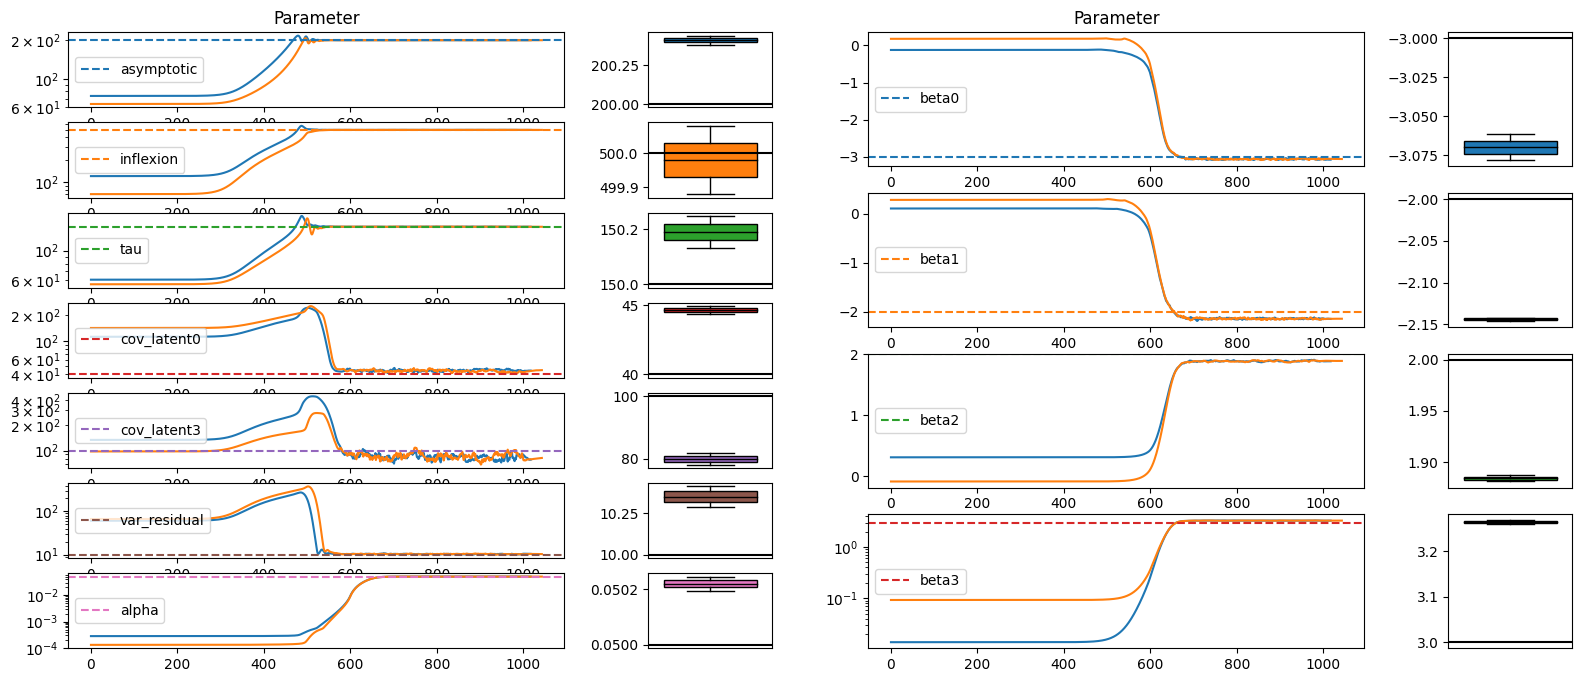

In [9]:
id_to_plot = [0, 1, 2, 3, 6, 7, 8]

fig = sdgplt.figure(8, 16)
subfigs = fig.subfigures(1, 4, wspace=0.07, width_ratios=[4, 1, 4, 1])
# subfigs = subfigs.reshape((subfigs.size,))

_ = sdgplt.plot_theta(
    multi_res,
    dim_ld=myModel.DIM_LD,
    params_star=myModel.hstack_params(p_star),
    params_names=myModel.params_names,
    id_to_plot=id_to_plot,
    log_scale=True,
    fig=subfigs[0],
)

f = sdgplt.boxplot_estimation(
    # multi_estim.last_theta.T,
    x=multi_res.last_theta.T[id_to_plot,],
    hline=myModel.hstack_params(p_star)[id_to_plot,],
    # xlabels=myModel.params_names,
    nrows=len(id_to_plot),
    ncols=1,
    fig=subfigs[1],
)

for ax in f.axes:
    ax.set_xlim(1 + 0.1 * jnp.array([-1, 1]))
    ax.get_yaxis().get_major_formatter().set_useOffset(False)
    ax.ticklabel_format(style="plain", axis="y")

_ = sdgplt.plot_theta_hd(
    multi_res,
    dim_ld=myModel.DIM_LD,
    params_star=myModel.hstack_params(p_star),
    params_names=myModel.params_names,
    fig=subfigs[2],
)

f = sdgplt.boxplot_estimation(
    multi_res.last_theta.T[myModel.DIM_LD :],
    hline=myModel.hstack_params(p_star)[myModel.DIM_LD :],
    # xlabels=myModel.params_names[myModel.DIM_LD :],
    nrows=myModel.P,
    ncols=1,
    fig=subfigs[3],
)
for ax in f.axes:
    ax.set_xlim(1 + 0.1 * jnp.array([-1, 1]))
    ax.get_yaxis().get_major_formatter().set_useOffset(False)
    ax.ticklabel_format(style="plain", axis="y")

In [10]:
sdgplt.get_dataframe_results(
    multi_res.last_theta, myModel.hstack_params(p_star), myModel.params_names
).style.format(
    {
        "real value": "{:.1f}".format,
        "mean": "{:.2f}".format,
        "variance": "{:.3f}".format,
        "rmse": "{:.4f}".format,
        "rrmse": "{:.1%}".format,
    }
)

,real value,mean,variance,rmse,rrmse
asymptotic,200.0,200.41,0.001,0.4104,0.2%
inflexion,500.0,499.98,0.010,0.1024,0.0%
tau,150.0,150.19,0.003,0.1984,0.1%
cov_latent0,40.0,44.68,0.074,4.6845,11.7%
cov_latent3,100.0,80.03,3.474,20.0575,20.1%
var_residual,10.0,10.35,0.004,0.3573,3.6%
alpha,0.1,0.05,0.000,0.0002,0.4%
beta0,-3.0,-3.07,0.000,0.0703,2.3%
beta1,-2.0,-2.14,0.000,0.1440,7.2%
beta2,2.0,1.88,0.000,0.1160,5.8%


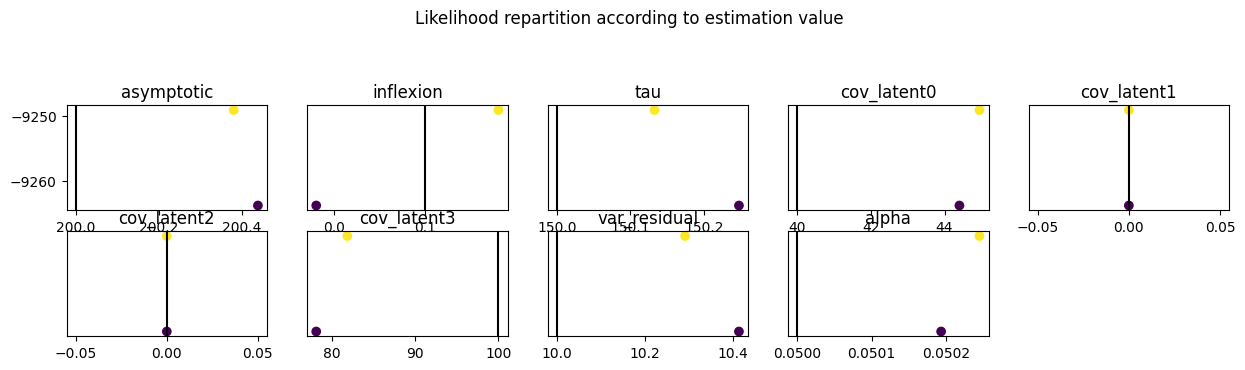

In [11]:
fig = sdgplt.scatter_estimation(
    multi_res.last_theta[:, : myModel.DIM_LD].T,
    multi_res.likelihood[:],
    vline=myModel.hstack_params(p_star)[: myModel.DIM_LD],
    labels=myModel.params_names[: myModel.DIM_LD],
    nrows=2,
    ncols=5,
    fig=sdgplt.figure(height=3, width=15),
)

_ = fig.suptitle("Likelihood repartition according to estimation value", y=1.2)

In [12]:
from sdg4varselect import regularization_path, lasso_into_estim
from sdg4varselect.outputs import RegularizationPathRes, MultiRunRes


def estim_with_flag(model, **kwargs) -> tuple[MultiRunRes, bool]:
    """must return the estimation results and
    a flag which indicates if the regularization path is finished"""
    res_estim = lasso_into_estim(one_estim, model=model, **kwargs)
    dim_ld = model.DIM_LD
    flag = (res_estim[-1].last_theta[dim_ld:] != 0).sum() == 0

    return res_estim, flag


def one_result(prngkey, model, data, lbd_set, save_all=True):

    list_sdg_results, bic = regularization_path(
        estim_fct_with_flag=estim_with_flag,
        prngkey=prngkey,
        lbd_set=lbd_set,
        dim_ld=model.DIM_LD,
        N=model.N * (1 + model.J),
        verbatim=True,  # __name__ == "__main__",
        # additional parameter
        model=model,
        data=data,
        save_all=save_all,
    )

    argmin_bic = bic[-1].argmin()

    return RegularizationPathRes(
        multi_run=list_sdg_results,
        argmin_bic=argmin_bic,
        bic=bic,
        lbd_set=lbd_set,
    )

In [13]:
myHDModel = WeibullCoxJM(myMeModel, P=10, alpha_scale=0.001, a=800, b=10)

p_star = myHDModel.new_params(
    mean_latent={"asymptotic": 200, "inflexion": 500},
    tau=150,
    cov_latent=jnp.diag(jnp.array([40, 100])),
    var_residual=10,
    alpha=0.05,
    beta=jnp.concatenate(  # jnp.zeros(shape=(myModel.P,)),  #
        [jnp.array([-3, -2, 2, 3]), jnp.zeros(shape=(myHDModel.P - 4,))]
    ),
)

myobs, _ = myHDModel.sample(p_star, jrd.PRNGKey(0), weibull_censoring_loc=7700)

0.00011473894119262695


In [26]:
lbd_set = 10 ** jnp.linspace(-1, 0, num=10)
reg = one_result(jrd.PRNGKey(0), myHDModel, myobs, lbd_set, save_all=False)
print(reg.chrono)

 0/10 [>                                                  ]
the model has been shrunk to P = 4
(200, 4)
 1/10 [=====>                                             ](end in ~ 0:48:49.917924 )
the model has been shrunk to P = 4
(200, 4)
 2/10 [==========>                                        ](end in ~ 0:29:51.052688 )
the model has been shrunk to P = 4
(200, 4)
 3/10 [===============>                                   ](end in ~ 0:20:07.617334 )
the model has been shrunk to P = 4
(200, 4)
 4/10 [====================>                              ](end in ~ 0:14:06.750666 )
the model has been shrunk to P = 4
(200, 4)
 5/10 [=========================>                         ](end in ~ 0:10:02.034610 )
the model has been shrunk to P = 3
(200, 3)
 6/10 [==============================>                    ](end in ~ 0:07:02.624144 )
the model has been shrunk to P = 2
(200, 2)
 7/10 [===================================>               ](end in ~ 0:04:44.428263 )
the model has been shrunk to P

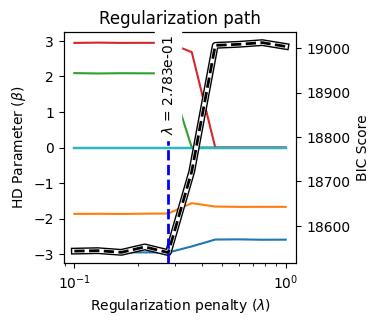

In [27]:
sdgplt.FIGSIZE = 3
fig = sdgplt.plot_reg_path(reg_res=reg, dim_ld=myHDModel.DIM_LD)

In [32]:
lbd_focus_set = 10 ** jnp.linspace(
    jnp.log10(lbd_set[reg.argmin_bic - 1]),
    jnp.log10(lbd_set[reg.argmin_bic + 1]),
    num=5,
)
reg_focus = one_result(jrd.PRNGKey(0), myHDModel, myobs, lbd_focus_set, save_all=False)

0/5 [>                                                  ]
the model has been shrunk to P = 4
(200, 4)
1/5 [==========>                                        ](end in ~ 0:36:27.741248 )
the model has been shrunk to P = 4
(200, 4)
2/5 [====================>                              ](end in ~ 0:18:30.383712 )
the model has been shrunk to P = 4
(200, 4)
3/5 [==============================>                    ](end in ~ 0:09:23.755980 )
the model has been shrunk to P = 4
(200, 4)
4/5 [========================================>          ](end in ~ 0:03:49.341056 )
the model has been shrunk to P = 3
(200, 3)


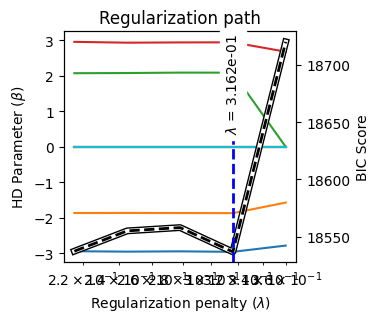

In [33]:
sdgplt.FIGSIZE = 3
fig = sdgplt.plot_reg_path(reg_res=reg_focus, dim_ld=myHDModel.DIM_LD)
fig.axes[0].rotating()